In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_ROOT = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")
IQ_DIR = DATASET_ROOT / "IQ"

first_iq = sorted(IQ_DIR.iterdir())[0]

print("IQ dosyası:", first_iq.name)

IQ dosyası: Combined_LTE_DSSS_frame_1


In [3]:
with open(first_iq, "rb") as file:
    file.seek(8)
    raw_data = np.fromfile(file, dtype=np.float32)

I = raw_data[0::2]
Q = raw_data[1::2]

iq = I + 1j * Q

print("IQ samples:", len(iq))

IQ samples: 614400


In [4]:
print("Mean I:", np.mean(I))
print("Mean Q:", np.mean(Q))
print("Mean IQ:", np.mean(iq))

Mean I: -0.0005283659
Mean Q: -6.444017e-05
Mean IQ: (-0.00052836625-6.444002e-05j)


In [5]:
amplitude = np.abs(iq)
rms = np.sqrt(np.mean(np.abs(iq) ** 2))

print("Amplitude mean:", np.mean(amplitude))
print("Amplitude max :", np.max(amplitude))
print("RMS           :", rms)

Amplitude mean: 1.5381087
Amplitude max : 6.0280027
RMS           : 1.7310002


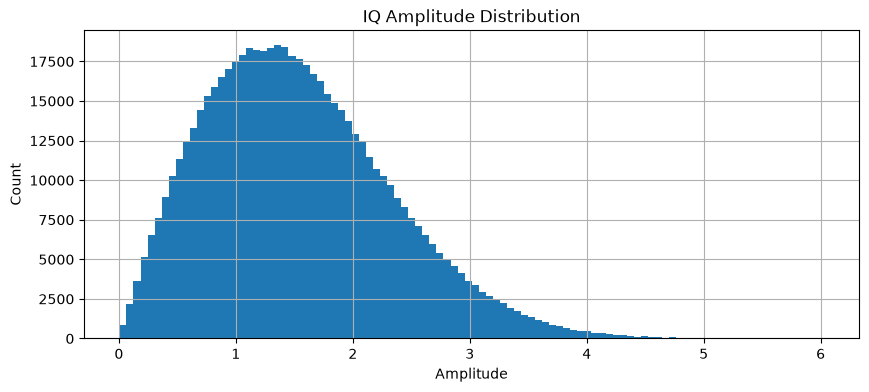

In [6]:
plt.figure(figsize=(10, 4))

plt.hist(amplitude, bins=100)

plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.title("IQ Amplitude Distribution")
plt.grid()

plt.show()

In [7]:
percentiles = [1, 5, 25, 50, 75, 95, 99, 99.9]

for p in percentiles:
    print(f"{p:>5}% :", np.percentile(amplitude, p))

    1% : 0.17670178
    5% : 0.39872485
   25% : 0.9403288
   50% : 1.4508462
   75% : 2.0370805
   95% : 2.9820848
   99% : 3.687115
 99.9% : 4.500659


In [8]:
iq_dc_removed = iq - np.mean(iq)

print("Original mean:", np.mean(iq))
print("After DC removal:", np.mean(iq_dc_removed))

Original mean: (-0.00052836625-6.444002e-05j)
After DC removal: (-5.4637592e-09+6.655852e-09j)


In [9]:
print("Original RMS:", np.sqrt(np.mean(np.abs(iq) ** 2)))
print("DC removed RMS:", np.sqrt(np.mean(np.abs(iq_dc_removed) ** 2)))

Original RMS: 1.7310002
DC removed RMS: 1.7310001


In [10]:
iq_peak_norm = iq / np.max(np.abs(iq))

print("Original max:", np.max(np.abs(iq)))
print("Normalized max:", np.max(np.abs(iq_peak_norm)))
print("Normalized RMS:", np.sqrt(np.mean(np.abs(iq_peak_norm) ** 2)))

Original max: 6.0280027
Normalized max: 0.99999994
Normalized RMS: 0.28715983


In [11]:
iq_rms_norm = iq / np.sqrt(np.mean(np.abs(iq) ** 2))

print("RMS after normalization:",
      np.sqrt(np.mean(np.abs(iq_rms_norm) ** 2)))

print("Max after normalization:",
      np.max(np.abs(iq_rms_norm)))

RMS after normalization: 1.0
Max after normalization: 3.4823813


In [12]:
print("Original mean amplitude:",
      np.mean(np.abs(iq)))

print("RMS-normalized mean amplitude:",
      np.mean(np.abs(iq_rms_norm)))

Original mean amplitude: 1.5381087
RMS-normalized mean amplitude: 0.8885665


In [13]:
N = 4096

fft_data = np.fft.fftshift(np.fft.fft(iq[:N]))
freq = np.fft.fftshift(np.fft.fftfreq(N, d=1 / 7_680_000))

magnitude = np.abs(fft_data)

print("FFT samples:", len(fft_data))
print("Frequency range:",
      freq.min() / 1e6,
      "to",
      freq.max() / 1e6,
      "MHz")

FFT samples: 4096
Frequency range: -3.84 to 3.838125 MHz


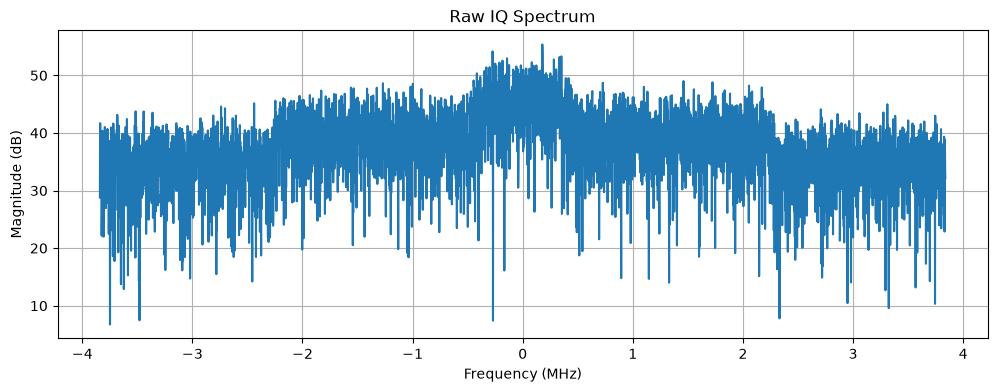

In [14]:
plt.figure(figsize=(12, 4))

plt.plot(freq / 1e6, 20 * np.log10(magnitude + 1e-12))

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("Raw IQ Spectrum")
plt.grid()

plt.show()

In [15]:
dc_region = np.abs(freq) < 50_000

dc_peak = np.max(magnitude[dc_region])
overall_peak = np.max(magnitude)

print("DC region peak:", dc_peak)
print("Overall peak:", overall_peak)
print("DC / Overall (dB):",
      20 * np.log10(dc_peak / overall_peak))

DC region peak: 386.74915
Overall peak: 586.5775
DC / Overall (dB): -3.617921


In [ ]:
## Preprocessing Decision

- IQ reconstruction: Interleaved I/Q confirmed.
- DC offset: Negligible; no mandatory DC removal.
- Peak normalization: Tested, but not selected as final preprocessing.
- RMS normalization: Tested, but not selected yet because it changes absolute amplitude information.
- Filtering: No filter applied at this stage. The spectrum does not provide sufficient evidence that filtering is necessary.
- Final preprocessing for the initial pipeline: Preserve the raw IQ signal.